In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
df = pd.read_csv("../data/Dataset .csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df[[
    "Has Table booking",
    "Has Online delivery",
    "Price range",
    "Aggregate rating"
]].head()

,Has Table booking,Has Online delivery,Price range,Aggregate rating
0,Yes,No,3,4.8
1,Yes,No,3,4.5
2,Yes,No,4,4.4
3,No,No,4,4.9
4,Yes,No,4,4.8


In [5]:
table_booking = df["Has Table booking"].value_counts()

table_booking

Has Table booking
No     8393
Yes    1158
Name: count, dtype: int64

In [6]:
table_booking_percent = (
    df["Has Table booking"]
    .value_counts(normalize=True)
    *100
).round(2)

table_booking_percent

Has Table booking
No     87.88
Yes    12.12
Name: proportion, dtype: float64

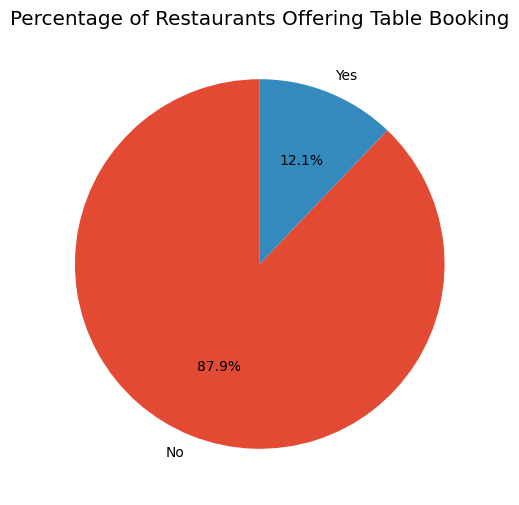

In [7]:
plt.figure(figsize=(6,6))

plt.pie(
    table_booking_percent,
    labels=table_booking_percent.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Restaurants Offering Table Booking")

plt.savefig("../images/table_booking_percentage.png", dpi=300)

plt.show()

In [8]:
delivery_percent = (
    df["Has Online delivery"]
    .value_counts(normalize=True)
    *100
).round(2)

delivery_percent

Has Online delivery
No     74.34
Yes    25.66
Name: proportion, dtype: float64

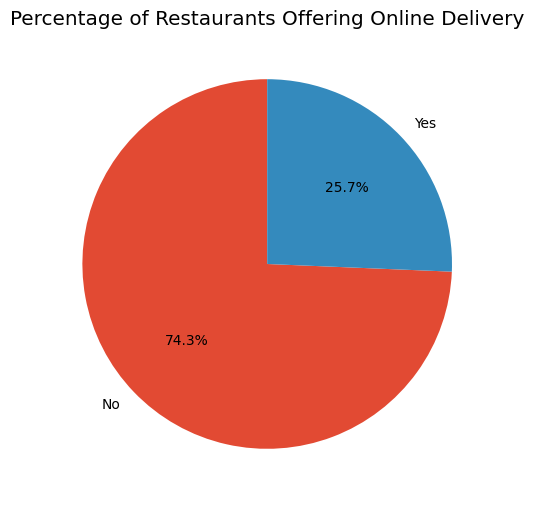

In [9]:
plt.figure(figsize=(6,6))

plt.pie(
    delivery_percent,
    labels=delivery_percent.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage of Restaurants Offering Online Delivery")

plt.savefig("../images/online_delivery_percentage.png", dpi=300)

plt.show()

In [10]:
rating_booking = df.groupby(
    "Has Table booking"
)["Aggregate rating"].mean()

rating_booking

Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64

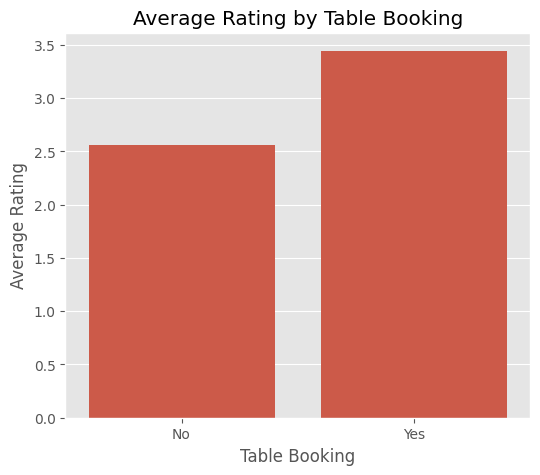

In [11]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=rating_booking.index,
    y=rating_booking.values
)

plt.title("Average Rating by Table Booking")

plt.xlabel("Table Booking")

plt.ylabel("Average Rating")

plt.savefig("../images/table_booking_rating.png", dpi=300)

plt.show()

In [12]:
delivery_price = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"]
)

delivery_price

Has Online delivery,No,Yes
Price range,,
1,3743,701
2,1827,1286
3,997,411
4,533,53


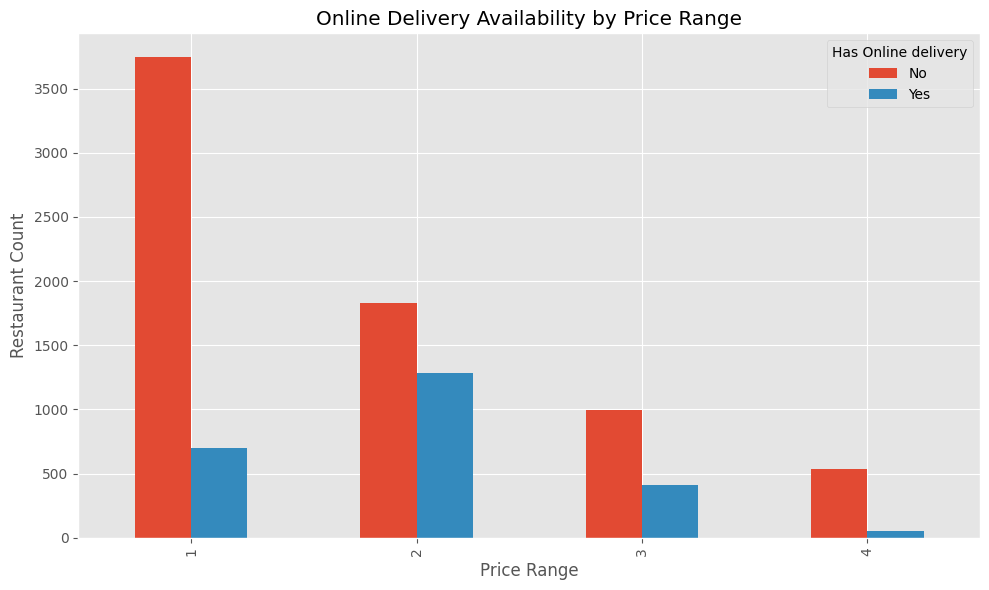

In [13]:
delivery_price.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Online Delivery Availability by Price Range")

plt.xlabel("Price Range")

plt.ylabel("Restaurant Count")

plt.tight_layout()

plt.savefig("../images/online_delivery_price_range.png", dpi=300)

plt.show()